In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
Path("../figs/eda/analysis").mkdir(parents=True, exist_ok=True)
con = duckdb.connect("../data/capstone.duckdb")

In [2]:
# Q1 - Products vs debit card usage

# Step 1: calculate total products per customer
product_query = con.execute("""
    SELECT 
        CustomerID,
        (CASE WHEN DepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN LoanAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN CreditCardAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN TimeDepositAccount = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN ActiveDebitCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN ActiveATMCard = 'Y' THEN 1 ELSE 0 END +
         CASE WHEN BangorWealth = true THEN 1 ELSE 0 END +
         CASE WHEN Payroll = true THEN 1 ELSE 0 END +
         CASE WHEN Merchant = true THEN 1 ELSE 0 END +
         CASE WHEN TPS = true THEN 1 ELSE 0 END +
         CASE WHEN PlingCustomer = true THEN 1 ELSE 0 END +
         CASE WHEN ABLECustomer = true THEN 1 ELSE 0 END) AS total_products
    FROM silver.customers
    WHERE Individual = 'Y'
""").fetchdf()

# Step 2: transaction metrics per customer
txn_query = con.execute("""
    SELECT
        CustomerID,
        COUNT(*) AS txn_count,
        SUM(Amount_Completed) AS total_spend,
        AVG(Amount_Completed) AS avg_txn_amount
    FROM silver.transactions
    WHERE Amount_Completed > 0
    GROUP BY CustomerID
""").fetchdf()

# Step 3: join and group by product count
df = product_query.merge(txn_query, on='CustomerID', how='inner')

result = df.groupby('total_products').agg(
    customer_count   = ('CustomerID', 'count'),
    avg_transactions = ('txn_count', 'mean'),
    avg_total_spend  = ('total_spend', 'mean'),
    avg_txn_amount   = ('avg_txn_amount', 'mean')
).round(2).reset_index()

print(result.to_string())

   total_products  customer_count  avg_transactions  avg_total_spend  avg_txn_amount
0               1           14196             63.03          3191.09           69.33
1               2           33373             63.11          3169.11           69.76
2               3            9958             62.34          3184.99           72.91
3               4            1187             56.46          2911.17           69.40
4               5             121             64.75          3432.77          181.34
5               6               8             54.00          2120.30           47.01


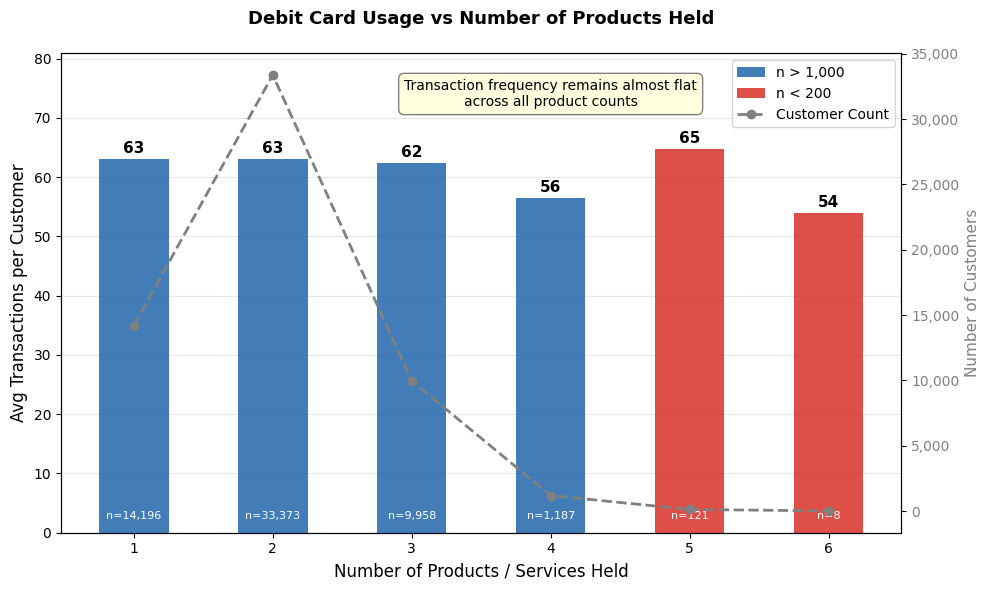

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 6))

colors = ['#2166ac'] * 4 + ['#d73027'] * 2  # red for small samples

bars = ax1.bar(result['total_products'], result['avg_transactions'],
               color=colors, alpha=0.85, width=0.5, zorder=3)

for bar, val, n in zip(bars, result['avg_transactions'], result['customer_count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2, 2,
             f'n={n:,}', ha='center', va='bottom', fontsize=8, color='white')

ax2 = ax1.twinx()
ax2.plot(result['total_products'], result['customer_count'],
         color='gray', marker='o', linewidth=2, markersize=6,
         linestyle='--', label='Customer Count')
ax2.set_ylabel('Number of Customers', color='gray', fontsize=11)
ax2.tick_params(axis='y', labelcolor='gray')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.set_xlabel('Number of Products / Services Held', fontsize=12)
ax1.set_ylabel('Avg Transactions per Customer', fontsize=12)
ax1.set_title('Debit Card Usage vs Number of Products Held\n',
              fontsize=13, fontweight='bold')
ax1.set_xticks(result['total_products'])
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.set_ylim(0, result['avg_transactions'].max() * 1.25)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', alpha=0.85, label='n > 1,000'),
    Patch(facecolor='#d73027', alpha=0.85, label='n < 200'),
    plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--',
               marker='o', label='Customer Count')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

# annotation with a simple text box
ax1.text(4, 72, 'Transaction frequency remains almost flat\nacross all product counts',
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig('../figs/eda/analysis/q1_products_vs_debit_usage.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Q4 — PBR vs non-PBR behavior
pbr_query = con.execute("""
    SELECT 
        c.PrimaryBankingCustomerFlag AS pbr,
        COUNT(DISTINCT txn_stats.CustomerID) AS customer_count,
        AVG(txn_stats.txn_count)             AS avg_transactions,
        AVG(txn_stats.total_spend)           AS avg_total_spend,
        AVG(txn_stats.avg_txn_amount)        AS avg_txn_amount
    FROM silver.customers c
    JOIN (
        SELECT 
            CustomerID,
            COUNT(*)              AS txn_count,
            SUM(Amount_Completed) AS total_spend,
            AVG(Amount_Completed) AS avg_txn_amount
        FROM silver.transactions
        WHERE Amount_Completed > 0
        GROUP BY CustomerID
    ) txn_stats ON c.CustomerID = txn_stats.CustomerID
    WHERE c.Individual = 'Y'
    GROUP BY c.PrimaryBankingCustomerFlag
""").fetchdf()

print(pbr_query.to_string())

  pbr  customer_count  avg_transactions  avg_total_spend  avg_txn_amount
0   N           19076          63.18096      3182.480797       69.556728
1   Y           39767          62.65758      3167.411815       70.817343


In [5]:
# Check PBR split in full customer base for context
con.execute("""
    SELECT 
        PrimaryBankingCustomerFlag,
        COUNT(*) as customer_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct
    FROM silver.customers
    WHERE Individual = 'Y'
    GROUP BY PrimaryBankingCustomerFlag
    ORDER BY customer_count DESC
""").fetchdf()

,PrimaryBankingCustomerFlag,customer_count,pct
0,Y,161473,68.3
1,N,74953,31.7


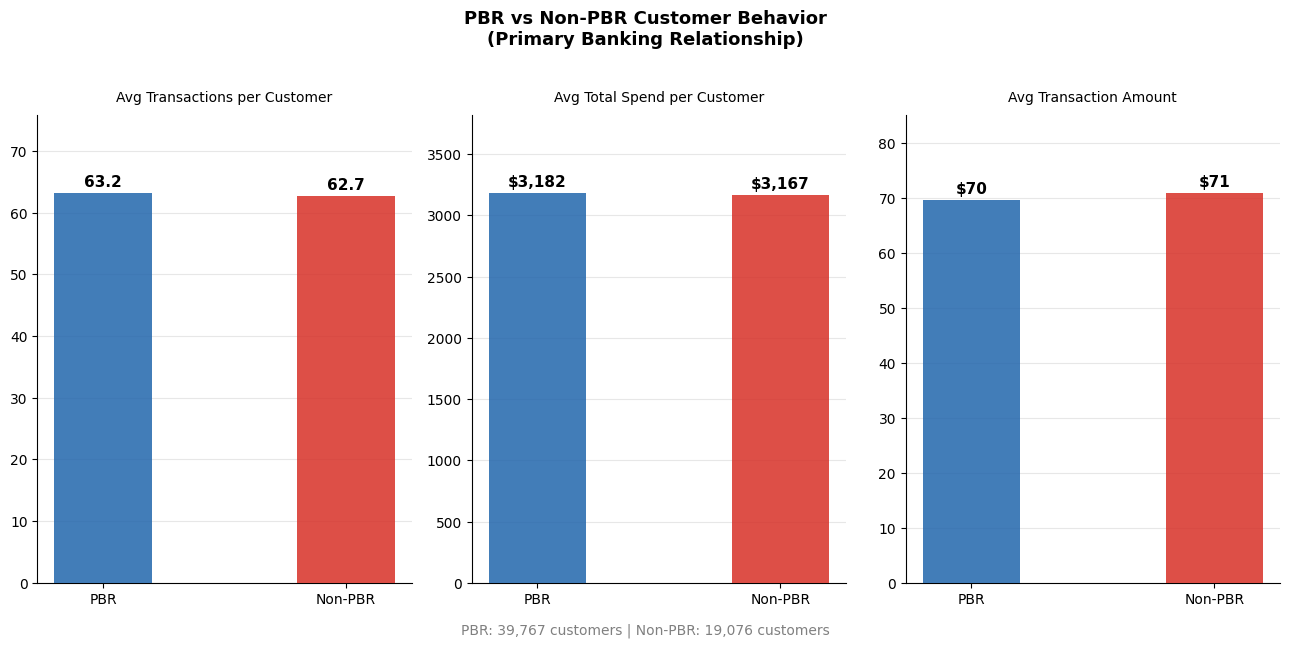

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 6))
fig.suptitle('PBR vs Non-PBR Customer Behavior\n(Primary Banking Relationship)',
             fontsize=13, fontweight='bold', y=1.02)

metrics = [
    ('avg_transactions', 'Avg Transactions per Customer', ''),
    ('avg_total_spend',  'Avg Total Spend per Customer',  '$'),
    ('avg_txn_amount',   'Avg Transaction Amount',        '$'),
]

colors = ['#2166ac', '#d73027']
labels = ['PBR', 'Non-PBR']

for ax, (col, title, prefix) in zip(axes, metrics):
    values = pbr_query[col].values
    bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.4, zorder=3)

    for bar, val in zip(bars, values):
        label = f'{prefix}{val:,.0f}' if prefix == '$' else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + values.max() * 0.01,
                label, ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Calculate difference
    # diff = ((values[0] - values[1]) / values[1]) * 100
    # ax.set_title(f'{title}\n({diff:+.1f}% difference)', fontsize=10, pad=10)
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_ylim(0, values.max() * 1.2)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Customer count context at bottom
fig.text(0.5, -0.02,
         f'PBR: {pbr_query[pbr_query.pbr=="Y"]["customer_count"].values[0]:,} customers | '
         f'Non-PBR: {pbr_query[pbr_query.pbr=="N"]["customer_count"].values[0]:,} customers',
         ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('../figs/eda/analysis/q4_pbr_vs_nonpbr.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
con.execute("""
    SELECT 
        CASE 
            WHEN c.Age = 0          THEN 'Age = 0'
            WHEN c.Age < 18         THEN 'Age < 18'
            WHEN c.Age >= 18        THEN 'Age >= 18'
            WHEN c.Age IS NULL      THEN 'Age NULL'
        END AS age_bucket,
        COUNT(DISTINCT t.CustomerID) AS customer_count
    FROM silver.customers c
    JOIN silver.transactions t ON c.CustomerID = t.CustomerID
    WHERE c.Individual = 'Y'
    GROUP BY age_bucket
    ORDER BY customer_count DESC
""").fetchdf()

,age_bucket,customer_count
0,Age >= 18,55817
1,Age < 18,2946
2,Age = 0,80


In [8]:
# Q3 — Age group transaction dip by category
# Step 1: transaction metrics by age group
age_query = con.execute("""
    SELECT 
        c.CustomerID,
        CASE 
            WHEN c.Age BETWEEN 18 AND 40 THEN 'Under 40'
            WHEN c.Age BETWEEN 41 AND 61 THEN '41 to 61'
            WHEN c.Age > 61            THEN 'Over 61'
            ELSE 'Unknown'
        END AS age_group,
        COUNT(t.Amount_Completed)    AS txn_count,
        SUM(t.Amount_Completed)      AS total_spend,
        AVG(t.Amount_Completed)      AS avg_txn_amount
    FROM silver.customers c
    JOIN silver.transactions t ON c.CustomerID = t.CustomerID
    WHERE c.Individual = 'Y'
      AND c.Age >= 18
      AND t.Amount_Completed > 0
    GROUP BY c.CustomerID, c.Age
""").fetchdf()

# Step 2: group by age bucket
result_age = age_query.groupby('age_group').agg(
    customer_count   = ('CustomerID', 'count'),
    avg_transactions = ('txn_count', 'mean'),
    avg_total_spend  = ('total_spend', 'mean'),
    avg_txn_amount   = ('avg_txn_amount', 'mean')
).round(2).reset_index()

# Sort in logical order
order = ['Under 40', '41 to 61', 'Over 61']
result_age['age_group'] = pd.Categorical(result_age['age_group'], categories=order, ordered=True)
result_age = result_age.sort_values('age_group').reset_index(drop=True)

print(result_age.to_string())

  age_group  customer_count  avg_transactions  avg_total_spend  avg_txn_amount
0  Under 40           19041             64.56          3226.91           69.03
1  41 to 61           17995             62.60          3161.95           70.73
2   Over 61           18781             61.04          3120.55           72.27


In [9]:
# Step 3 — category spend shares by age group
category_age_query = con.execute("""
    SELECT 
        CASE 
            WHEN c.Age BETWEEN 18 AND 40 THEN 'Under 40'
            WHEN c.Age BETWEEN 41 AND 61 THEN '41 to 61'
            WHEN c.Age > 61              THEN 'Over 61'
        END AS age_group,
        m.category,
        SUM(t.Amount_Completed) AS total_spend
    FROM silver.customers c
    JOIN silver.transactions t
        ON c.CustomerID = t.CustomerID
    LEFT JOIN gold.mrt_mcc_categories m
        ON t.Merchant_Category = m.merchant_category
    WHERE c.Individual = 'Y'
      AND c.Age >= 18
      AND t.Amount_Completed > 0
      AND m.category != 'Other'
    GROUP BY age_group, m.category
""").fetchdf()

# Calculate share within each age group
category_age_query['group_total'] = category_age_query.groupby('age_group')['total_spend'].transform('sum')
category_age_query['spend_share'] = (category_age_query['total_spend'] / category_age_query['group_total'] * 100).round(2)

# Pivot for easy comparison
pivot = category_age_query.pivot(index='category', columns='age_group', values='spend_share').round(2)
pivot = pivot[['Under 40', '41 to 61', 'Over 61']]
pivot['dip_vs_under40'] = (pivot['41 to 61'] - pivot['Under 40']).round(2)
pivot = pivot.sort_values('dip_vs_under40')

print(pivot.to_string())

age_group              Under 40  41 to 61  Over 61  dip_vs_under40
category                                                          
Retail                    14.15     13.88    14.08           -0.27
Gas                        8.81      8.56     8.45           -0.25
Automotive                 2.87      2.65     3.14           -0.22
Electronics/Computers      3.48      3.36     3.51           -0.12
Financial Services        10.46     10.39    10.24           -0.07
Telecom/Cable              4.61      4.56     4.53           -0.05
Dining                    10.47     10.47    10.10            0.00
Transportation             0.55      0.56     0.52            0.01
Entertainment/Leisure      3.27      3.29     2.95            0.02
Government/Community       2.10      2.14     2.30            0.04
Clothing                   1.82      1.86     1.74            0.04
Home/Hardware              3.70      3.75     3.82            0.05
Pets                       1.38      1.43     1.39            

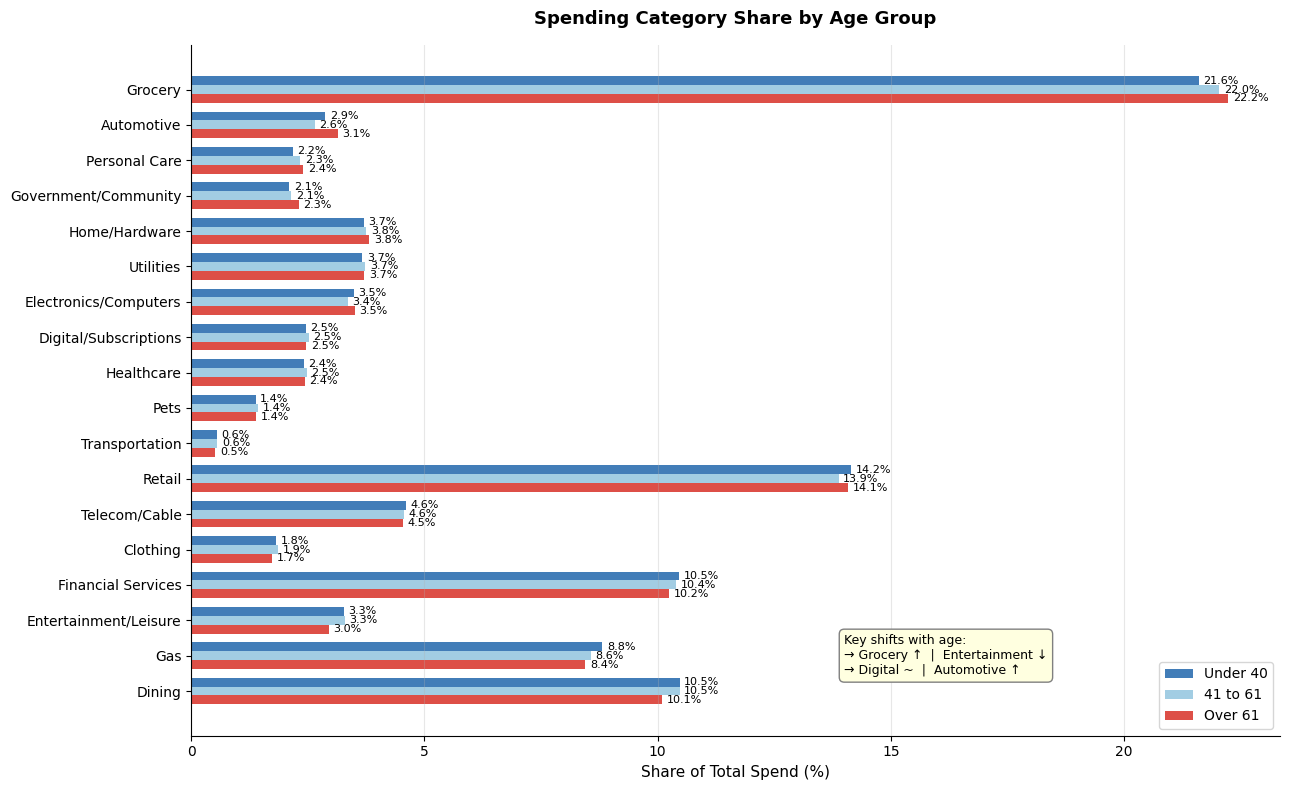

In [10]:
# Sort by the overall shift from Under 40 to Over 61
pivot['total_shift'] = pivot['Over 61'] - pivot['Under 40']
pivot_sorted = pivot.sort_values('total_shift')

categories = pivot_sorted.index.tolist()
under40  = pivot_sorted['Under 40'].values
mid      = pivot_sorted['41 to 61'].values
over61   = pivot_sorted['Over 61'].values

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 8))

bars1 = ax.barh(x + width, under40, width, label='Under 40',  color='#2166ac', alpha=0.85)
bars2 = ax.barh(x,          mid,     width, label='41 to 61', color='#92c5de', alpha=0.85)
bars3 = ax.barh(x - width,  over61,  width, label='Over 61',  color='#d73027', alpha=0.85)

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.1, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', ha='left', fontsize=8)

ax.set_yticks(x)
ax.set_yticklabels(categories, fontsize=10)
ax.set_xlabel('Share of Total Spend (%)', fontsize=11)
ax.set_title('Spending Category Share by Age Group',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation box for trends
ax.text(14, 1, 
        'Key shifts with age:\n→ Grocery ↑  |  Entertainment ↓\n→ Digital ~  |  Automotive ↑',
        fontsize=9, va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig('../figs/eda/analysis/q3_category_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
con.close()